# Credit Application Governance Analysis

This notebook presents the data engineering workflow for the **Credit Application Governance project**, conducted as part of the *Data Ecosystems and Governance in Organizations* course.

The objective of this analysis is to examine a dataset of credit applications provided by NovaCred in order to identify **data quality issues, potential bias patterns, and governance risks** associated with automated lending decisions.

The notebook focuses on the **data engineering stage** of the project, including:

- loading and structuring the raw nested dataset
- performing a data quality audit across key dimensions (completeness, consistency, validity, accuracy, and uniqueness)
- identifying and quantifying data quality issues
- implementing a structured data cleaning and remediation pipeline
- producing a cleaned dataset suitable for downstream analysis

The resulting dataset will be used by the data science stage of the project to investigate **bias in lending decisions and fairness metrics**, as well as by the governance analysis to evaluate **privacy and regulatory implications**.

# Import Libraries


In [489]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## **1. Load and Flatten Raw JSON Dataset**

The dataset is stored as a **nested JSON document**, where each record represents a credit application containing:  

- **Applicant information**
- **Financial indicators**
- **Spending behaviour**
- **The final lending decision**

To prepare the data for analysis, the nested structure is **flattened** using `pandas.json_normalize()`, converting nested attributes into columns so that each row corresponds to a credit application and each column represents a specific attribute.


In [490]:
file_path = "../data/raw/raw_credit_applications.json"

with open(file_path, "r") as f:
    raw = json.load(f)

df_raw = pd.json_normalize(raw, sep=".")
print("First 5 rows of the flattened DataFrame:")
print(df_raw.head())


First 5 rows of the flattened DataFrame:
       _id                                  spending_behavior  \
0  app_200  [{'category': 'Shopping', 'amount': 480}, {'ca...   
1  app_037  [{'category': 'Rent', 'amount': 608}, {'catego...   
2  app_215              [{'category': 'Rent', 'amount': 109}]   
3  app_024           [{'category': 'Fitness', 'amount': 575}]   
4  app_184     [{'category': 'Entertainment', 'amount': 463}]   

   processing_timestamp applicant_info.full_name        applicant_info.email  \
0  2024-01-15T00:00:00Z              Jerry Smith   jerry.smith17@hotmail.com   
1                   NaN           Brandon Walker   brandon.walker2@yahoo.com   
2                   NaN              Scott Moore      scott.moore94@mail.com   
3                   NaN               Thomas Lee  thomas.lee6@protonmail.com   
4  2024-01-15T00:00:00Z          Brian Rodriguez   brian.rodriguez86@aol.com   

  applicant_info.ssn applicant_info.ip_address applicant_info.gender  \
0        596-64

## **2. Dataset Overview**

Before performing data quality checks, we inspect the structure of the dataset to identify the number of variables, their data types, and detect potential isssues such as missing values, inconsistent formats, or type mismatches.

In [491]:
print("DataFrame Info:")
df_raw.info()


missing_values_pct = (df_raw.isnull().sum() / len(df_raw)* 100).sort_values(ascending=False)
print("\nMissing Values Percentages:")
print(missing_values_pct[missing_values_pct > 0].round(1), '%')


print("\nColumn names:")
for col in df_raw.columns:
    print(f"- {col}")


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    str    
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     str    
 3   applicant_info.full_name          502 non-null    str    
 4   applicant_info.email              502 non-null    str    
 5   applicant_info.ssn                497 non-null    str    
 6   applicant_info.ip_address         497 non-null    str    
 7   applicant_info.gender             501 non-null    str    
 8   applicant_info.date_of_birth      501 non-null    str    
 9   applicant_info.zip_code           501 non-null    str    
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  fin

### Initial Observations

From the dataset initial inspection, several important observations emerge:

- The dataset contains **502 records and 21 variables**. Each record represents a credit application entry, although further validation is required to determine whether all records correspond to unique applications or if duplicate entries are present.

- Several attributes appear optional or sparsely populated, suggesting possible **schema inconsistencies or incomplete data collection**. This is evidenced by **significant missing values**, particularly in the following fields:
  - `notes` (99.6% missing)
  - `financials.annual_salary` (99% missing)
  - `loan_purpose` (90% missing)
  - `processing_timestamp` (87.6% missing)
  - `decision.rejection_reason` (58.2% missing)
  - `decision.approved_amount` (41.8% missing)
  - `decision.interest_rate` (41.8% missing)

- The variable `financials.annual_income` is stored as an **object rather than a numeric type**. Additionally, temporal variables such as `processing_timestamp` and `applicant_info.date_of_birth` are stored as strings rather than datetime objects, necessitating type conversion.

- The `spending_behavior` field contains **nested JSON/objects**, requiring flattening or transformation before further detailed analysis.

These findings confirm signifcant **data quality issues that must be addressed to ensure the integrity of subsequent bias analysis and governance evaluations.**

## **3. Data Quality Audit**
### **3.1 Completeness**

#### 3.1.1 Missing Values (NaN)
Missing information reduces the reliability of the data and affects downstream analyses such as bias detection or model evaluation.

The presence of **null values across all variables** is examined to identify and quantify attributes with incomplete records.


In [492]:
missing_count = df_raw.isnull().sum()
missing_percentage = (missing_count / len(df_raw)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percentage.round(2)
}).sort_values("Percentage (%)", ascending=False)

missing_table.head(21) 


,Missing Values,Percentage (%)
notes,500,99.60
financials.annual_salary,497,99.00
loan_purpose,452,90.04
processing_timestamp,440,87.65
decision.rejection_reason,292,58.17
decision.approved_amount,210,41.83
decision.interest_rate,210,41.83
financials.annual_income,5,1.00
applicant_info.ip_address,5,1.00
applicant_info.ssn,5,1.00


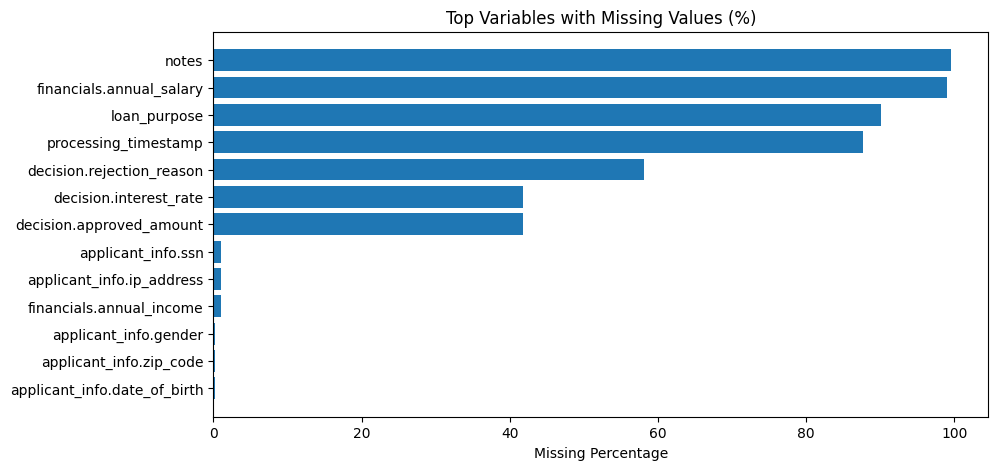

In [493]:
# Display the top 15 variables with the highest missing value percentages
top = missing_table[missing_table["Percentage (%)"] > 0].head(15).sort_values("Percentage (%)")
plt.figure(figsize=(10,5))
plt.barh(top.index, top["Percentage (%)"])
plt.title("Top Variables with Missing Values (%)")
plt.xlabel("Missing Percentage")
plt.show()


#### Findings:

The analysis reveals substantial variation in data completeness across variables.

- Several attributes, such as `notes`, `financials.annual_salary`, `loan_purpose`, and `processing_timestamp`, exhibit very high missingness levels, suggesting that they may be optional or inconsistently captured during data collection.

- Decision-related attributes (`decision.rejection_reason`, `decision.interest_rate` and `decision.approved_amount`) are missing for a subset of records.

- In contrast, financial indicators such as `financials.debt_to_income` and `financials.credit_history_months` show no missing values, indicating that these variables are consistently recorded and likely required for the lending decision process.

#### Structural Missingness vs. Random Missingness:

Not all missing values necessarily indicate data quality problems. In some cases, missing values occur by design because certain variables are only relevant under specific conditions:

- The variables `decision.interest_rate` and `decision.approved_amount` are populated only when a loan application is approved. Missing values in these fields therefore represent **structural missingness**, consistent with the decision logic of the lending process.

- In contrast, missing values observed in the remaining attributes such as `processing_timestamp`, `loan_purpose`, or certain applicant information fields  represent **non-structural missingness**, which may indicate incomplete data collection or inconsistencies in the data ingestion process.

In [494]:
df_raw.groupby("decision.loan_approved")[["decision.interest_rate","decision.approved_amount"]].count()


,decision.interest_rate,decision.approved_amount
decision.loan_approved,,
False,0,0
True,292,292


#### 3.1.2 Empty String Values
Missing information may also appear in the form of **empty strings ("")**. Unlike null values, empty strings are not automatically detected as missing by most data analysis tools and may therefore obscure incomplete data.

The dataset is therefore examined to identify variables where empty strings are used instead of proper null values.

In [495]:
empty_counts = (df_raw == "").sum()
empty_string_table=pd.DataFrame({"Empty String Count": empty_counts[empty_counts > 0]}).sort_values("Empty String Count",ascending=False)
empty_string_table.head()


,Empty String Count
applicant_info.email,7
applicant_info.date_of_birth,4
applicant_info.gender,2
applicant_info.zip_code,1


#### Findings:

This analysis shows that in certain variables **missing information is enconded as strings rather than proper null entries**, indicating inconsistencies in how missing data is represented and may hinder accurate detection of incomplete records during analysis.

To ensure consistent handling of missing values, empty string entries are standardised by converting them to null values (`NaN`). 

### **3.2 Consistency**

Inconsistent encodings, formats, or schema definitions can lead to inaccurate aggregations and misleading analytical results. 

The dataset is examined for inconsistencies in:
- Categorical Encodings
- Date Formats
- Schema Structure

#### 3.2.1 Categorical Values Consistency

Categorical variables should use a consistent representation for each category. The `applicant_info.gender` variable is examined to identify potential inconsistencies in category encoding.

In [496]:
print("\nUnique values and counts for 'applicant_info.gender':")
print(df_raw['applicant_info.gender'].value_counts(dropna=False))



Unique values and counts for 'applicant_info.gender':
applicant_info.gender
Male      195
Female    193
F          58
M          53
            2
NaN         1
Name: count, dtype: int64


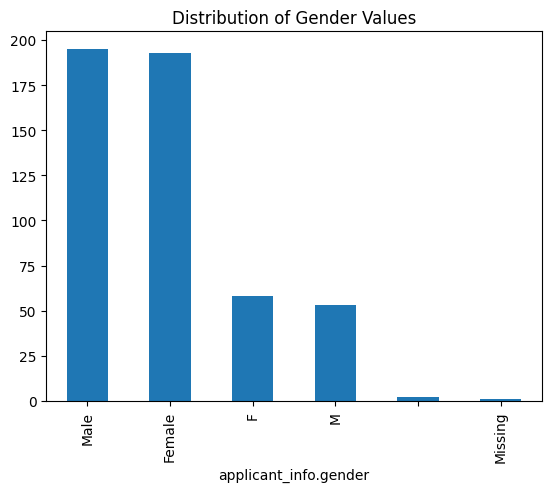

In [497]:
df_raw["applicant_info.gender"].fillna("Missing").astype(str).value_counts().plot(kind="bar")
plt.title("Distribution of Gender Values")
plt.show()


#### Findings:

The gender variable contains multiple encodings for the same categories, including `"Male"` and `"M"`, as well as `"Female"` and `"F"`. Additionally, three records contain missing values for this variable.

If treated as separate categories, such inconsistencies may distort statistical analysis and bias detection. Standardising categorical values is therefore necessary to ensure consistent interpretation across the dataset.

#### 3.2.2 Date Format Consistency

Date variables should also follow a consistent format to enable reliable parsing and chronological analysis.

The `applicant_info.date_of_birth` field is inspected to identify potential inconsistencies in date representation.

In [498]:
print("Sample of Date of Birth Values:")
df_raw["applicant_info.date_of_birth"].dropna().astype(str).sample(15, random_state=42)


Sample of Date of Birth Values:


362    1994-07-07
73     1978-10-04
375    1993-12-13
155    1987/04/13
104    1985-11-10
395    1990-11-30
378    08/26/1983
124    06/10/1993
68     1985-11-09
451    05/21/1984
9      1989-10-10
194    1999-08-28
407    1963-05-16
84     1973-01-23
486    2000/04/13
Name: applicant_info.date_of_birth, dtype: str

#### Findings:

The date of birth variable contains multiple formatting styles, including ISO formats (`YYYY-MM-DD`) and alternatives such as `DD/MM/YYYY` and `YYYY/MM/DD`.

Mixed formats may lead to parsing errors or incorrect age calculations in downstream analysis. Standardising the date format would improve temporal data processing.

#### 3.2.3 Schema Consistency

Consistency should also be maintained at the schema level. Attributes representing the same concept should not appear under multiple column names.

The dataset is inspected to identify variables that may represent similar information but are stored in separate fields.

In [499]:
print("Count of non-null values in variables with the same concept:")
df_raw[["financials.annual_income","financials.annual_salary"]].count()


Count of non-null values in variables with the same concept:


financials.annual_income    497
financials.annual_salary      5
dtype: int64

#### Findings:

The dataset contains both `financials.annual_income` and `financials.annual_salary`, which appear to represent similar financial attributes.

However, the two variables are populated very differently. While `financials.annual_income` contains values for the majority of records, `financials.annual_salary` contains only a small number of entries.

This pattern suggests a schema inconsistency, potentially resulting from incomplete schema migration or inconsistent data ingestion practices.

In [500]:
print("Main Consistency Issues Identified:")
pd.DataFrame({
    "Issue Type": [
        "Categorical encoding inconsistency",
        "Date format inconsistency",
        "Schema inconsistency"
    ],
    "Affected Variables": [
        "applicant_info.gender",
        "applicant_info.date_of_birth",
        "financials.annual_income / financials.annual_salary"
    ]
})


Main Consistency Issues Identified:


,Issue Type,Affected Variables
0,Categorical encoding inconsistency,applicant_info.gender
1,Date format inconsistency,applicant_info.date_of_birth
2,Schema inconsistency,financials.annual_income / financials.annual_s...


### **3.3 Validity**
Invalid data may arise from **type mismatches** (e.g., temporal values stored as string or numeric values stored as object) or from **numeric values falling outside plausible business ranges**.

This section evaluates:

- whether attributes can be interpreted using appropriate numeric or temporal types  
- whether numeric values fall within logically plausible 

#### 3.3.1 Data Type Validity

Variables should be stored using appropriate data types to ensure reliable computation and analysis. 
However, during data ingestion or transformation processes, attributes containing numerical or temporal information may be stored as string/object.

This section identifies variables whose stored type may not match their intended semantic type.

In [501]:
print("Data types of each attribute:")
print(df_raw.dtypes)


Data types of each attribute:
_id                                     str
spending_behavior                    object
processing_timestamp                    str
applicant_info.full_name                str
applicant_info.email                    str
applicant_info.ssn                      str
applicant_info.ip_address               str
applicant_info.gender                   str
applicant_info.date_of_birth            str
applicant_info.zip_code                 str
financials.annual_income             object
financials.credit_history_months      int64
financials.debt_to_income           float64
financials.savings_balance            int64
decision.loan_approved                 bool
decision.rejection_reason               str
loan_purpose                            str
decision.interest_rate              float64
decision.approved_amount            float64
financials.annual_salary            float64
notes                                   str
dtype: object


#### Findings:

Most attributes follow appropriate data types.  However, the following variables expected to support numerical or temporal analysis are stored as string or object types:
- `financials.annual_income`: appears as an object rather than a numeric variable  
- `applicant_info.date_of_birth` and `processing_timestamp`: stored as strings instead of datetime objects

Additionally, the nested structure of `spending_behavior` must be validated to ensure that spending categories are stored as strings and transaction amounts as numeric values, allowing the variable to be used in subsequent analytical computations.

**Remediation Step**: The `financials.annual_income` field must be converted to a numeric data type to enable further validation.

In [502]:
print("Current financials.annual_income dtype:", df_raw["financials.annual_income"].dtype)
income_numeric = pd.to_numeric(df_raw["financials.annual_income"], errors="coerce")
non_convertible_values = df_raw["financials.annual_income"].notna() & income_numeric.isna() # Identify values that could not be converted
print("Non-convertible income values:", non_convertible_values.sum())
print("Missing income values:", df_raw["financials.annual_income"].isna().sum())

# First Remediation Step required for Numeric Range Validity. 
if non_convertible_values.sum() == 0:
    df_raw["financials.annual_income"] = income_numeric

print("Current financials.annual_income dtype:", df_raw["financials.annual_income"].dtype)


Current financials.annual_income dtype: object
Non-convertible income values: 0
Missing income values: 5
Current financials.annual_income dtype: float64


#### Findings:

The variable `financials.annual_income` is initially stored as an **object** instead of a numeric type.

The validation check confirms that non-null values can be interpreted as numeric values, indicating that the object type is primarily due to the presence of missing values rather than inconsistent formatting.

The column is therefore **converted to a numeric type** to support subsequent validation steps, namely numeric range checks.

In [503]:
temporal_columns = [
    "processing_timestamp",
    "applicant_info.date_of_birth"
]

results = []

for col in temporal_columns:
    parsed = pd.to_datetime(df_raw[col], errors="coerce")

    invalid_dates = df_raw[col].notna().sum() - parsed.notna().sum()

    results.append({
        "column": col,
        "stored_dtype": df_raw[col].dtype,
        "missing_values": df_raw[col].isna().sum(),
        "non_parsable_dates": invalid_dates
    })

pd.DataFrame(results)


,column,stored_dtype,missing_values,non_parsable_dates
0,processing_timestamp,str,440,0
1,applicant_info.date_of_birth,str,1,161


#### Findings:

Temporal attributes such as `applicant_info.date_of_birth` and `processing_timestamp` are stored as string values.

Results indicate that for `processing_timestamp`, the string type is primarily due to a high number of missing values, while `applicant_info.date_of_birth` contains a significant number of non-parsable entries (157), suggesting formatting inconsistencies.

Converting these attributes to datetime types after proper cleaning would improve reliability for time-based analysis.

In [504]:
# check the strcture of spending_behavior due to possibility of data type issues
# Nested field validation: ensure structured fields (e.g., spending_behavior) have expected key types (Category string, Amount integer)
invalid_category_type = 0
invalid_amount_type = 0
invalid_structure = 0

for entry in df_raw["spending_behavior"].dropna():

    # ensure the entry is a list of transactions
    if not isinstance(entry, list):
        invalid_structure += 1
        continue

    for transaction in entry:

        if not isinstance(transaction, dict):
            invalid_structure += 1
            continue

        # check category type
        if not isinstance(transaction.get("category"), str):
            invalid_category_type += 1

        # check amount type
        if not isinstance(transaction.get("amount"), int):
            invalid_amount_type += 1


print("Invalid structures:", invalid_structure)
print("Invalid category types (not string):", invalid_category_type)
print("Invalid amount types (not integer):", invalid_amount_type)


Invalid structures: 0
Invalid category types (not string): 0
Invalid amount types (not integer): 0


#### Findings:
The `spending_behavior` variable is of type object due to its nested dictionary-based structure. 
Its structure inspection  ensures `category` values are stored as strings and `amount` values are stored as integers, validating the field for latter aggregation and analysis. 

### 3.3.2 Numeric Range Validity

Numeric attributes should fall within logically plausible ranges. Values that are extreme or illogical (e.g., negative balances or ratios outside expected limits) may indicate data entry errors or data processing issues.

This section inspects the distribution of numeric variables and highlights potential anomalies that require further review.

In [505]:
numerical_columns = df_raw.select_dtypes(include=["int64", "float64"]).columns
print("\nDescriptive statistics for numerical columns:")
df_raw[numerical_columns].describe().round(2)



Descriptive statistics for numerical columns:


,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.interest_rate,decision.approved_amount,financials.annual_salary
count,497.00,502.00,502.00,502.00,292.00,292.00,5.00
mean,82705.10,50.40,0.25,29493.50,4.56,47845.89,69200.00
std,28101.98,31.23,0.14,16775.31,1.16,18103.75,22664.95
min,0.00,-10.00,0.05,-5000.00,2.50,15000.00,45000.00
25%,63000.00,27.25,0.15,17258.25,3.50,34000.00,46000.00
50%,81000.00,48.00,0.23,27385.50,4.55,48000.00,75000.00
75%,101000.00,72.00,0.35,38251.50,5.60,62250.00,86000.00
max,171000.00,133.00,1.85,88078.00,6.50,80000.00,94000.00


In [506]:
range_checks = []

for col in numerical_columns:

    negative_values = (df_raw[col] < 0).sum()

    range_checks.append({
        "column": col,
        "min": df_raw[col].min(),
        "max": df_raw[col].max(),
        "negative_values": negative_values
    })

pd.DataFrame(range_checks)


,column,min,max,negative_values
0,financials.annual_income,0.00,171000.00,0
1,financials.credit_history_months,-10.00,133.00,2
2,financials.debt_to_income,0.05,1.85,0
3,financials.savings_balance,-5000.00,88078.00,1
4,decision.interest_rate,2.50,6.50,0
5,decision.approved_amount,15000.00,80000.00,0
6,financials.annual_salary,45000.00,94000.00,0


In [507]:
invalid_credit_history = (df_raw["financials.credit_history_months"] < 0).sum()

invalid_dti = (
    (df_raw["financials.debt_to_income"] < 0) |
    (df_raw["financials.debt_to_income"] > 1)
).sum()

invalid_savings = (df_raw["financials.savings_balance"] < 0).sum()

print("Negative credit history months:", invalid_credit_history)
print("Debt-to-income outside [0,1]:", invalid_dti)
print("Negative savings balance:", invalid_savings)


Negative credit history months: 2
Debt-to-income outside [0,1]: 1
Negative savings balance: 1


#### Findings:

The range checks flagged a small number of implausible values that should be reviewed during cleaning:
- `financials.credit_history_months`: 2 records with negative values
- `financials.debt_to_income`: 1 record outside the expected ratio range [0, 1]
- `financials.savings_balance`: 1 record with a negative balance

### 3.4 Uniqueness

In [508]:
# Duplicate entries based on application ID
duplicate_count = df_raw["_id"].duplicated().sum()
duplicate_percentage = (duplicate_count / len(df_raw) * 100).round(2)
print("Duplicate application IDs:", duplicate_count)
print("Percentage of duplicate application IDs:", duplicate_percentage)

duplicate_ids = df_raw[df_raw["_id"].duplicated(keep=False)]["_id"].unique()
print("\nDuplicated IDs:", duplicate_ids)

duplicated_records = df_raw[df_raw["_id"].isin(duplicate_ids)] # full duplicated records
duplicated_records


Duplicate application IDs: 2
Percentage of duplicate application IDs: 0.4

Duplicated IDs: <StringArray>
['app_042', 'app_001']
Length: 2, dtype: str


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR


#### Findings:
The uniqueness check identifies **2 duplicated application IDs**, showing that the applications **app_001** and **app_042** appear more than once in the dataset, due to duplicate entry error and resubmission, consequently.

Duplicate records can lead to biased statistics and incorrect model training results. Deduplication should therefore be performed during the data cleaning stage, ensuring each application is uniquely represented.

### **3.5 Accuracy**

Accuracy refers to whether recorded data correctly represents the real-world entities it describes.

Since external ground truth is unavailable, accuracy is assessed through internal logical consistency checks. In particular, the decision outcome should align with related financial attributes such as approved loan amount and interest rate.

For example:
- **Rejected applications** should not have an approved amount or interest rate.
- **Approved applications** should include both an approved amount and an interest rate.

In [509]:
#decision structural logic (rejected → rate/amount = NaN)
approved = df_raw["decision.loan_approved"] == True
rejected = df_raw["decision.loan_approved"] == False

viol_rejected_has_amount = (rejected & df_raw["decision.approved_amount"].notna()).sum()
viol_rejected_has_rate = (rejected & df_raw["decision.interest_rate"].notna()).sum()

viol_approved_missing_amount = (approved & df_raw["decision.approved_amount"].isna()).sum()
viol_approved_missing_rate = (approved & df_raw["decision.interest_rate"].isna()).sum()

accuracy_checks = {
    "Rejected with approved amount": viol_rejected_has_amount,
    "Rejected with interest rate": viol_rejected_has_rate,
    "Approved missing amount": viol_approved_missing_amount,
    "Approved missing interest rate": viol_approved_missing_rate
}

pd.DataFrame.from_dict(accuracy_checks, orient="index", columns=["violations"])


,violations
Rejected with approved amount,0
Rejected with interest rate,0
Approved missing amount,0
Approved missing interest rate,0


#### Findings:

The consistency checks reveal **no accuracy violations** in the dataset:

- No rejected applications contain an approved loan amount or interest rate.
- No approved applications are missing the corresponding approved amount or interest rate.

This suggests that the decision outcome and associated financial attributes are internally consistent. While full accuracy cannot be confirmed without external validation sources, the dataset shows no internal inconsistencies in these key decision variables.

### Data Quality Audit Summary

The data quality audit identified several issues affecting the reliability and analytical usability of the dataset.

Key findings:

- **High missingness:** Some attributes contain substantial missing data, including `notes` (99.6%), `loan_purpose` (90.0%), and `processing_timestamp` (87.6%).
- **Empty string values:** Some attributes (`applicant_info.email`, `applicant_info.data_of_birth`, `applicant_info.gender`,`applicant_info.zip_code`) contained empty strings used to represent missing information, requiring standardisation to `NaN`.
- **Inconsistent categorical encoding:** The `applicant_info.gender` variable used multiple representations for the same categories (e.g., `Male`/`M`, `Female`/`F`), and also contained missing values.
- **Inconsistent data formats:** `applicant_info.data_of_birth` contained multiple date formats.
- **Schema redundancy:** Two variables (`financials.annual_income` and `financials.annual_salary`) represent the same income attribute.
- **Inconsistent data types:** Three variables expected to support numerical or temporal analysis were stored as object / strings (`financials.annual_income`, `applicant_info.date_of_birth`, and `processing_timestamp`).
- **Nested data structures:** The `spending_behavior` variable stores transaction data as lists of dictionaries, requiring transformation into tabular features.
- **Implausible financial values:** Four records violate expected numeric ranges (e.g., negative credit history or savings balances and debt-to-income ratios above 1).
- **Duplicate identifiers:** Two duplicated application IDs (app_001 and app_042) were identified.

These issues are addressed in the following section through a structured data cleaning and remediation pipeline.


## 4. Data Cleaning / Remediation Pipeline

Based on the issues identified during the data quality audit, targeted remediation steps are applied to improve the dataset.

The cleaning pipeline focuses on:
- **4.1** Creating a working copy
- **4.2** Standardising missing values
- **4.3** Consolidating duplicated schema fields 
- **4.4** Converting variables to appropriate data types
- **4.5** Standardizing categorical values
- **4.6** Removing duplicated applications
- **4.7** Dropping high-noise columns based on a threshold
- **4.8** Correcting implausible numeric values
- **4.9** Deriving application age 
- **4.10** Transforming nested spending data into tabular features
- **4.11** Sorting dataset by the application identifier
- **4.12** Renaming variables
- **4.13** Exporting dataset to the processed data directory

The resulting dataset is intended to support downstream bias, fairness, and governance analysis.

Note: one remediation step was processed during the data quality audit:
- `financials.annual_income` was converted from object data type to float data type

### 4.1 Create a Working Copy

A copy of the raw dataset is created so that cleaning steps can be applied without altering the original data.

In [510]:
df = df_raw.copy() #generate the clean dataset from a copy of the raw_credit_applications dataset

print("Initial dataset shape:", df.shape)


Initial dataset shape: (502, 21)


### 4.2 Standardise Missing Values (empty strings to NaN)

Empty strings are converted to `NaN` so that missing information is represented consistently acrross the dataset. 

In [511]:
empty_before = (df == "").sum().sum()

df = df.replace("", np.nan)

empty_after = (df == "").sum().sum() # verify if empty string entries were successfully converted to NaN

print("Empty strings before:", empty_before)
print("Empty strings after:", empty_after)


Empty strings before: 14
Empty strings after: 0


### 4.3 Consolidate Income Variables

The dataset contains two overlapping variables representing annual income: `financials.annual_income` and `financials.annual_salary`.

Missing values in `financials.annual_income` are filled using `financials.annual_salary`, after which the redundant salary column is removed.

In [512]:
if "financials.annual_salary" in df.columns:

    income_missing_before = df["financials.annual_income"].isna().sum()

    df["financials.annual_income"] = df["financials.annual_income"].where(
        df["financials.annual_income"].notna(),
        df["financials.annual_salary"]
    )

    income_missing_after = df["financials.annual_income"].isna().sum()

    print("Income values filled from salary:", income_missing_before - income_missing_after)

    df = df.drop(columns=["financials.annual_salary"])

    print("Column financials.annual_salary removed.")


Income values filled from salary: 5
Column financials.annual_salary removed.


### 4.4 Convert Temporal Variables

Temporal variables are converted to datetime format to support chronological analysis.

In [513]:
# Standardize date of birth and processing timestamp to datetime, using the 'mixed' format parser
date_cols = [
    "processing_timestamp",
    "applicant_info.date_of_birth"
]

for col in date_cols:

    if col in df.columns:

        df[col] = pd.to_datetime(df[col], dayfirst=True, format="mixed")

        print(col, "converted to datetime.")

    missing_after = df[col].isnull().sum()
    print("Missing values after:", missing_after) #to check if the parsing format was correct


processing_timestamp converted to datetime.
Missing values after: 440
applicant_info.date_of_birth converted to datetime.
Missing values after: 5


In [514]:
print("Data types after conversion:")
print(df.dtypes)


Data types after conversion:
_id                                                 str
spending_behavior                                object
processing_timestamp                datetime64[us, UTC]
applicant_info.full_name                            str
applicant_info.email                                str
applicant_info.ssn                                  str
applicant_info.ip_address                           str
applicant_info.gender                               str
applicant_info.date_of_birth             datetime64[us]
applicant_info.zip_code                             str
financials.annual_income                        float64
financials.credit_history_months                  int64
financials.debt_to_income                       float64
financials.savings_balance                        int64
decision.loan_approved                             bool
decision.rejection_reason                           str
loan_purpose                                        str
decision.interest_r

### 4.5 Standardise Categorical Values

Inconsistent categorical encodings are standardised to improve comparability across records.

In [515]:
if "applicant_info.gender" in df.columns:

    print("Gender value counts (before):")
    print(df["applicant_info.gender"].value_counts(dropna=False))

    df["applicant_info.gender"] = df["applicant_info.gender"].replace({
        "M": "Male",
        "F": "Female",
    })
    
    print("\nGender value counts (after):")
    print(df["applicant_info.gender"].value_counts(dropna=False))


Gender value counts (before):
applicant_info.gender
Male      195
Female    193
F          58
M          53
NaN         3
Name: count, dtype: int64

Gender value counts (after):
applicant_info.gender
Female    251
Male      248
NaN         3
Name: count, dtype: int64


### 4.6 Remove Duplicate Applications

Duplicate application IDs are removed to ensure that each record corresponds to a unique application.

In [516]:
# Deduplicate: keep least missing per _id
duplicate_count = df["_id"].duplicated().sum()
print("Duplicated application IDs:", duplicate_count)

duplicate_ids = df[df["_id"].duplicated(keep=False)]["_id"].unique()
print("Duplicated IDs:", duplicate_ids)

df["_missing"] = df.isna().sum(axis=1)
df = df.sort_values(["_id", "_missing"]).drop_duplicates("_id", keep="first").drop(columns="_missing")
print("\nCurrent number of records after deduplication:", len(df))


duplicate_count_after_deduplication = df["_id"].duplicated().sum()
print("\nDuplicate application IDs after deduplication:", duplicate_count_after_deduplication)
print("\nDataset shape after deduplication:", df.shape)


Duplicated application IDs: 2
Duplicated IDs: <StringArray>
['app_042', 'app_001']
Length: 2, dtype: str

Current number of records after deduplication: 500

Duplicate application IDs after deduplication: 0

Dataset shape after deduplication: (500, 20)


### 4.7 Drop Highly Incomplete Columns

Columns with very high missingness provide limited analytical value and may introduce noise.  
A threshold of **60% missing values** is applied. Columns exceeding this threshold are considered unreliable for analysis and are removed.
This decision aligns with data quality principles:

• **Completeness** – columns with too many missing values provide little analytical value  
• **Reliability** – highly sparse columns may introduce bias or instability in models  
• **Data minimization** – unnecessary fields should not be retained

The removed columns are listed below for transparency.

In [517]:
# Remove columns exceeding missing value threshold
threshold = 60  # %
missing_pct = df.isna().mean() * 100
columns_to_remove = missing_pct[missing_pct > threshold].index.tolist()

print("Columns exceeding missingness threshold:", columns_to_remove)

df = df.drop(columns=columns_to_remove, errors="ignore")

print("Dataset shape after removing highly incomplete columns:", df.shape)


Columns exceeding missingness threshold: ['processing_timestamp', 'loan_purpose', 'notes']
Dataset shape after removing highly incomplete columns: (500, 17)


### 4.8 Correct Implausible Numeric Values

Values that violate basic plausibility rules are standardised to `NaN` so that they do not distort subsequent analysis.

In [518]:
# Validity fixes: Set impossible financial values to NaN for later handling
# credit history cannot be negative
if "financials.credit_history_months" in df.columns:

    invalid = (df["financials.credit_history_months"] < 0).sum()

    df.loc[df["financials.credit_history_months"] < 0,
           "financials.credit_history_months"] = np.nan

    print("Invalid credit_history_months corrected:", invalid)


# savings balance should not be negative
if "financials.savings_balance" in df.columns:

    invalid = (df["financials.savings_balance"] < 0).sum()

    df.loc[df["financials.savings_balance"] < 0,
           "financials.savings_balance"] = np.nan

    print("Invalid savings_balance corrected:", invalid)


# debt to income ratio should be between 0 and 1
if "financials.debt_to_income" in df.columns:

    invalid = ((df["financials.debt_to_income"] < 0) |
               (df["financials.debt_to_income"] > 1)).sum()

    df.loc[(df["financials.debt_to_income"] < 0) |
           (df["financials.debt_to_income"] > 1),
           "financials.debt_to_income"] = np.nan

    print("Invalid debt_to_income values corrected:", invalid)


Invalid credit_history_months corrected: 2
Invalid savings_balance corrected: 1
Invalid debt_to_income values corrected: 1


### 4.9 Derive Applicant Age

Applicant age is calculated from date of birth to create a more directly interpretable feature for later analysis.

In [519]:
if "applicant_info.date_of_birth" in df.columns:
    today = pd.Timestamp.today().normalize()
    df["applicant_age"] = ((today - df["applicant_info.date_of_birth"]).dt.days // 365).astype("Int64")

    print("applicant_age variable created.")


applicant_age variable created.


In [520]:
df.head()


,_id,spending_behavior,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,decision.interest_rate,decision.approved_amount,applicant_age
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,102000.0,37.0,0.42,0.0,False,high_dti_ratio,NaN,NaN,39
339,app_002,"[{'category': 'Education', 'amount': 533}]",Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,Male,1999-01-08,10020,41000.0,5.0,0.36,18200.0,False,algorithm_risk_score,NaN,NaN,27
284,app_003,"[{'category': 'Healthcare', 'amount': 450}]",Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,Female,1982-08-24,90213,65000.0,74.0,0.43,7090.0,True,NaN,3.4,76000.0,43
255,app_004,"[{'category': 'Transportation', 'amount': 329}...",Karen Nelson,karen.nelson35@outlook.com,486-50-5539,172.31.79.76,Female,1995-02-28,90217,69000.0,9.0,0.41,10327.0,False,high_dti_ratio,NaN,NaN,31
136,app_005,"[{'category': 'Insurance', 'amount': 585}]",Christine Mitchell,christine.mitchell3@outlook.com,400-91-8156,172.25.44.173,Female,1960-06-19,90296,39000.0,76.0,0.06,15011.0,False,algorithm_risk_score,NaN,NaN,65


### 4.10 Transform Spending Behavior

The `spending_behavior` variable contains nested transaction data and is not directly usable in tabular analysis.

It is therefore transformed into aggregated features capturing:

- total spending
- number of spending entries
- category-level spending totals

The original nested column is removed after feature extraction to avoid redundancy.

In [521]:
# Spending features: total + count + per-category totals
if "spending_behavior" in df.columns:

    def agg(sb):
        if not isinstance(sb, list):
            return {"spend_total": 0.0, "spend_n": 0}

        total = 0.0
        n = 0
        cats = {}

        for item in sb:
            if not isinstance(item, dict):
                continue

            cat = item.get("category", "unknown")
            cat = str(cat).strip().lower()

            amt = item.get("amount", None)
            amt = pd.to_numeric(amt, errors="coerce")  
            if pd.isna(amt):
                continue

            amt = float(amt)
            total += amt
            n += 1
            cats[cat] = cats.get(cat, 0.0) + amt

        out = {"spend_total": total, "spend_n": n}

        for k, v in cats.items():
            k_clean = (
                str(k)
                .replace(" ", "_")
                .replace("-", "_")
                .replace("/", "_")
            )
            out[f"spend_{k_clean}"] = v

        return out


    # Build features dataframe
    spend_feats = pd.DataFrame([agg(x) for x in df["spending_behavior"]], index=df.index)

    # Fill missing feature columns with 0 (important for modeling later)
    spend_feats = spend_feats.fillna(0)

    # Merge features back
    df = pd.concat([df, spend_feats], axis=1)

    # Dropping raw nested column (avoid redundancy)
    df = df.drop(columns=["spending_behavior"])

    print("spending_behavior converted into tabular features and removed.")


spending_behavior converted into tabular features and removed.


### 4.11 Application Ordering
After cleaning and transformation, the dataset is sorted by the application identifier (`_id`) to ensure consistent ordering after cleaning..  

In [522]:
df = df.sort_values("_id").reset_index(drop=True)

print("Final dataset shape:", df.shape)


Final dataset shape: (500, 34)


### 4.12 Column Renaming

Nested JSON field names from the raw dataset contain long hierarchical prefixes  (e.g., `applicant_info.gender`, `financials.annual_income`), so to improve readability and facilitate downstream analysis, these fields are renamed to simpler, model-friendly column names while preserving their semantic meaning.

In [523]:
# Rename to simpler modeling-friendly names
rename_map = {
    "_id": "application_id",
    "applicant_info.full_name": "full_name",
    "applicant_info.email": "email",
    "applicant_info.ssn": "ssn",
    "applicant_info.ip_address": "ip_address",
    "applicant_info.gender": "gender",
    "applicant_info.date_of_birth": "date_of_birth",
    "applicant_info.zip_code": "zip_code",
    "financials.annual_income": "annual_income",
    "financials.credit_history_months": "credit_history_months",
    "financials.debt_to_income": "debt_to_income",
    "financials.savings_balance": "savings_balance",
    "decision.loan_approved": "loan_approved",
    "decision.interest_rate": "interest_rate",
    "decision.approved_amount": "approved_amount",
    "decision.rejection_reason": "rejection_reason",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})


In [524]:
df.head()


,application_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,...,spend_insurance,spend_shopping,spend_utilities,spend_entertainment,spend_rent,spend_dining,spend_gambling,spend_travel,spend_adult_entertainment,spend_alcohol
0,app_001,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,102000.0,37.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,app_002,Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,Male,1999-01-08,10020,41000.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,app_003,Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,Female,1982-08-24,90213,65000.0,74.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,app_004,Karen Nelson,karen.nelson35@outlook.com,486-50-5539,172.31.79.76,Female,1995-02-28,90217,69000.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_005,Christine Mitchell,christine.mitchell3@outlook.com,400-91-8156,172.25.44.173,Female,1960-06-19,90296,39000.0,76.0,...,585.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4.13 Dataset Export

The cleaned dataset is exported to the `processed` data directory.

At this stage the dataset has been:

- cleaned and standardised
- deduplicated
- transformed into a fully tabular structure
- renamed with analysis-friendly column names

The resulting file will be used for downstream data science and bias analysis tasks.

In [525]:
OUT_PATH = "../data/processed/clean_credit_applications.csv"
df.to_csv(OUT_PATH, index=False)
OUT_PATH, df.shape


('../data/processed/clean_credit_applications.csv', (500, 34))

### Post-clean validation

After applying the cleaning and remediation pipeline, a validation step is performed to verify that the dataset is consistent and ready for downstream analysis.

This validation focuses on:

- reviewing the remaining proportion of missing values across variables
- confirming that duplicate application identifiers have been removed
- ensuring the dataset structure is consistent after transformations

The objective is to confirm that the main data quality issues identified during the audit have been successfully addressed.

#### Missing Values After Cleaning

The distribution of missing values is re-evaluated after the remediation pipeline.

Most variables now contain minimal missing data, while higher missingness remains only in attributes that are logically conditional on loan decisions:

- `rejection_reason` is missing for approved applications
- `approved_amount` and `interest_rate` are missing for rejected applications

These remaining missing values therefore reflect **business logic rather than data quality issues**.

Final dataset shape: (500, 34)

Remaining missing values:
rejection_reason         0.584
approved_amount          0.416
interest_rate            0.416
email                    0.014
applicant_age            0.008
ssn                      0.008
ip_address               0.008
date_of_birth            0.008
gender                   0.004
credit_history_months    0.004
savings_balance          0.002
debt_to_income           0.002
zip_code                 0.002
spend_entertainment      0.000
spend_rent               0.000
dtype: float64


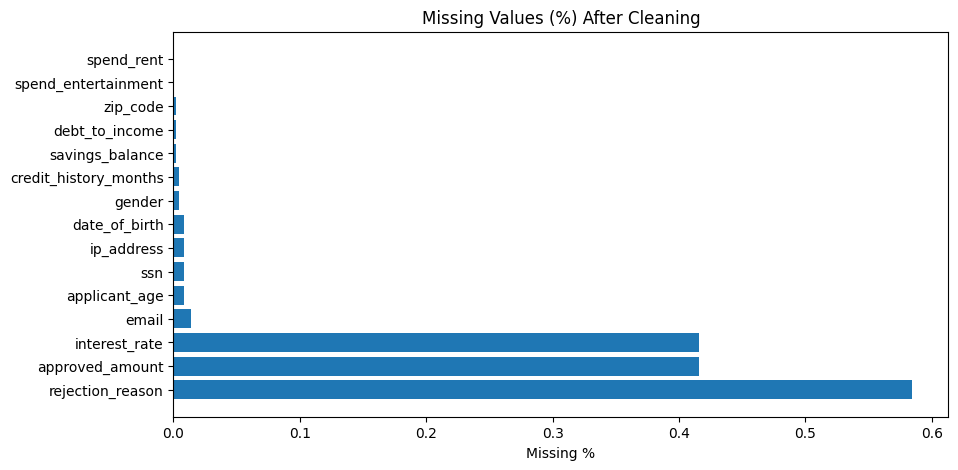

In [ ]:
print("Final dataset shape:", df.shape)
print("\nRemaining missing values:")
print(df.isna().mean().sort_values(ascending=False).head(15))

top_after = df.isna().mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
plt.barh(top_after.index, top_after.values)
plt.title("Missing Values (%) After Cleaning")
plt.xlabel("Missing %")
plt.show()


#### Duplicate Validation

The dataset is checked again to confirm that duplicate application identifiers have been removed.

The result shows **zero duplicated `application_id` values**, confirming that each record now represents a unique credit application.

In [ ]:
duplicates = df["application_id"].duplicated().sum()

print("Duplicate application IDs after cleaning:", duplicates)


Duplicate application IDs after cleaning: 0


## Cleaning Pipeline Outcome

The final cleaned dataset contains **500 applications and 34 variables**.

The remediation pipeline successfully addressed the main issues identified during the data quality audit, including:

- inconsistent data types
- redundant schema fields
- nested spending behavior structures
- implausible financial values
- duplicated application identifiers

A final validation confirms that the dataset structure is consistent and suitable for downstream analysis.

The resulting dataset is therefore prepared for **bias detection, fairness evaluation, and governance analysis** in the subsequent stages of the project.